# Baseline por Proyecto: Modelos Preentrenados sin Fine-tuning
### Proyecto I: Introducción a LLMs — Facultad de Ciencias, UNAM — Semestre 2026-2

---

> **Objetivo de la sesión:** Establecer un baseline funcional para cada proyecto *antes* de hacer fine-tuning. Un baseline es el punto de partida medido: ¿qué tan bien funciona un modelo preentrenado sin ninguna adaptación a tu tarea? Todo lo que hagamos después se compara contra este número.

**¿Por qué empezar aquí y no con fine-tuning?**
1. Un buen modelo preentrenado puede sorprenderte — a veces el baseline ya es suficiente
2. Sin baseline no sabes si el fine-tuning mejoró algo
3. Es mucho más rápido: hoy terminas la sesión con resultados concretos

**Mapa de la sesión:**
```
Parte 0: El pipeline de HuggingFace                    (10 min)
Parte 1: Análisis de sentimiento — reseñas Google Maps (20 min) ★
Parte 2: Clasificación zero-shot — sin datos propios   (15 min) ★
Parte 3: Chatbot con modelo generativo — joyería       (20 min) ★
Parte 4: Medir el baseline — métricas para cada uno   (15 min)
```
★ = cada sección corresponde a un proyecto del grupo

**Infraestructura:** Colab con GPU T4 (Entorno de ejecución → Cambiar tipo → T4 GPU)

In [ ]:
!pip install transformers torch datasets scikit-learn --quiet

import torch
from transformers import pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
device_name = 'GPU' if device == 0 else 'CPU'
print(f"Dispositivo: {device_name}")
print("Todo listo.")

Dispositivo: GPU
Todo listo.


---
## Parte 0: El Pipeline de HuggingFace

`pipeline()` es la abstracción de alto nivel de HuggingFace: descarga un modelo preentrenado, lo configura para una tarea, y expone una interfaz simple. Internamente hace exactamente lo que vimos en el notebook anterior — tokenización, forward pass, decodificación — pero empaquetado.

```python
# Lo que hace pipeline() internamente:
# 1. Tokenizer:  texto → token ids
# 2. Modelo:     token ids → logits
# 3. Postproceso: logits → etiqueta + probabilidad
```

Las tareas disponibles relevantes para este curso:

| `task` | Modelo típico | Caso de uso |
|:---|:---|:---|
| `sentiment-analysis` | BERT fine-tuneado | Reseñas, opiniones |
| `zero-shot-classification` | BART-MNLI | Clasificación sin datos |
| `text-generation` | GPT-2, Mistral | Chatbots, completado |
| `question-answering` | BERT-QA | QA extractivo |
| `summarization` | T5, BART | Resumen de documentos |

In [ ]:
# Pipeline más simple posible — 3 líneas
clasificador = pipeline('sentiment-analysis', device=device)

resultado = clasificador("I absolutely loved this product!")
print(resultado)
# → [{'label': 'POSITIVE', 'score': 0.9998}]

# Por defecto usa 'distilbert-base-uncased-finetuned-sst-2-english'
# En las siguientes partes usaremos modelos más apropiados para cada proyecto

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998822212219238}]


---
## Parte 1: Análisis de Sentimiento — Reseñas de Google Maps
### *(Proyecto: análisis de sentimiento en reseñas)*

Google Maps usa estrellas del 1 al 5. El proyecto busca clasificar automáticamente el sentimiento de las reseñas en texto.

**Decisión de modelo:** Las reseñas pueden estar en español o inglés. Usaremos `nlptown/bert-base-multilingual-uncased-sentiment`, un BERT multilingüe fine-tuneado específicamente en reseñas de 1-5 estrellas de Yelp, Amazon y TripAdvisor en varios idiomas incluyendo español.

Este modelo es un buen baseline porque:
- Entiende español nativamente
- Ya fue entrenado en reseñas (dominio cercano a Google Maps)
- Predice directamente 1-5 estrellas

In [ ]:
print("Cargando modelo multilingüe de sentimiento...")
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    device=device
)
print("Listo.")
print(f"Modelo: nlptown/bert-base-multilingual-uncased-sentiment")
print(f"Etiquetas: 1 star → 5 stars (escala de reseñas)")

Cargando modelo multilingüe de sentimiento...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Listo.
Modelo: nlptown/bert-base-multilingual-uncased-sentiment
Etiquetas: 1 star → 5 stars (escala de reseñas)


In [ ]:
# Dataset de ejemplo: reseñas de Google Maps en español
# En el proyecto real, este dataset vendrá de scraping o descarga de la API

resenas_ejemplo = [
    # (texto, estrellas_reales, categoria)
    ("Excelente servicio, el lugar está muy limpio y el personal es muy amable. Definitivamente regresaré.", 5, "positiva"),
    ("La comida estaba deliciosa, los precios son justos y la atención fue rápida. Lo recomiendo.", 5, "positiva"),
    ("Buen lugar en general, aunque el tiempo de espera fue un poco largo. La comida compensó.", 4, "positiva"),
    ("Servicio regular, no fue lo que esperaba pero tampoco estuvo mal. Quizás lo intente de nuevo.", 3, "neutral"),
    ("Ni bueno ni malo. El lugar es bonito pero el servicio dejó mucho que desear.", 3, "neutral"),
    ("Tardaron demasiado en atendernos y la comida llegó fría. No lo recomendaría.", 2, "negativa"),
    ("Pésimo servicio, nos cobraron de más y cuando reclamamos fueron muy groseros.", 1, "negativa"),
    ("Terrible experiencia. La comida tenía mal sabor y el lugar estaba sucio. Nunca regreso.", 1, "negativa"),
    # Casos difíciles
    ("La comida está bien pero el servicio es lento. Tiene potencial pero le falta mejorar.", 3, "neutral"),
    ("No entiendo por qué tiene tantas reseñas positivas. A mí no me pareció para nada especial.", 2, "negativa"),
    ("Amazing food! Best tacos I've had in Mexico City. Will definitely come back!", 5, "positiva"),
    ("Disappointing. Expected much more based on the reviews. Very overrated place.", 2, "negativa"),
]

textos = [r[0] for r in resenas_ejemplo]
estrellas_reales = [r[1] for r in resenas_ejemplo]
categorias_reales = [r[2] for r in resenas_ejemplo]

print(f"Dataset de ejemplo: {len(resenas_ejemplo)} reseñas")
print(f"Distribución: {pd.Series(categorias_reales).value_counts().to_dict()}")

Dataset de ejemplo: 12 reseñas
Distribución: {'negativa': 5, 'positiva': 4, 'neutral': 3}


In [ ]:
# Correr el baseline
resultados = sentiment_pipe(textos, truncation=True, max_length=512)

# Mapear etiquetas del modelo ("1 star"..."5 stars") a nuestras categorías
def estrellas_a_categoria(label):
    n = int(label[0])  # "3 stars" → 3
    if n >= 4: return 'positiva'
    if n == 3: return 'neutral'
    return 'negativa'

estrellas_pred = [int(r['label'][0]) for r in resultados]
categorias_pred = [estrellas_a_categoria(r['label']) for r in resultados]
confianzas = [r['score'] for r in resultados]

# Mostrar predicciones
print(f"{'Reseña':>50} | {'Real':>8} | {'Pred':>8} | {'Conf':>6} | {'OK'}")
print("-" * 85)
for texto, cat_r, cat_p, conf in zip(textos, categorias_reales, categorias_pred, confianzas):
    ok = '✓' if cat_r == cat_p else '✗'
    print(f"{texto[:50]:>50} | {cat_r:>8} | {cat_p:>8} | {conf:.3f} | {ok}")

                                            Reseña |     Real |     Pred |   Conf | OK
-------------------------------------------------------------------------------------
Excelente servicio, el lugar está muy limpio y el  | positiva | positiva | 0.759 | ✓
La comida estaba deliciosa, los precios son justos | positiva | positiva | 0.519 | ✓
Buen lugar en general, aunque el tiempo de espera  | positiva | positiva | 0.578 | ✓
Servicio regular, no fue lo que esperaba pero tamp |  neutral |  neutral | 0.747 | ✓
Ni bueno ni malo. El lugar es bonito pero el servi |  neutral | negativa | 0.547 | ✗
Tardaron demasiado en atendernos y la comida llegó | negativa | negativa | 0.584 | ✓
Pésimo servicio, nos cobraron de más y cuando recl | negativa | negativa | 0.877 | ✓
Terrible experiencia. La comida tenía mal sabor y  | negativa | negativa | 0.953 | ✓
La comida está bien pero el servicio es lento. Tie |  neutral |  neutral | 0.609 | ✓
No entiendo por qué tiene tantas reseñas positivas | negativa 

BASELINE — Análisis de Sentimiento (sin fine-tuning)
Modelo: nlptown/bert-base-multilingual-uncased-sentiment

              precision    recall  f1-score   support

    negativa       0.83      1.00      0.91         5
     neutral       1.00      0.67      0.80         3
    positiva       1.00      1.00      1.00         4

    accuracy                           0.92        12
   macro avg       0.94      0.89      0.90        12
weighted avg       0.93      0.92      0.91        12



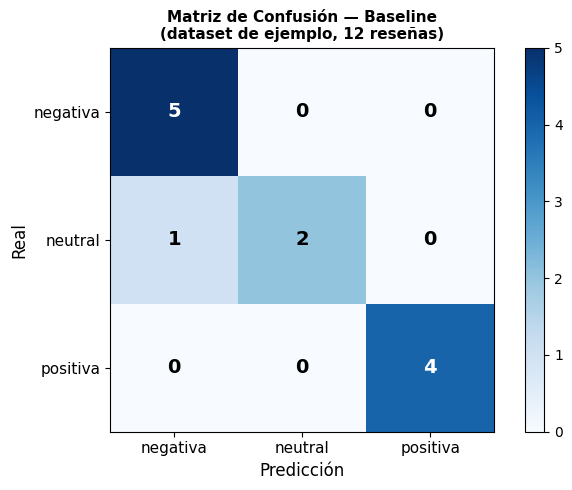


Accuracy baseline: 91.7%

Este número es tu punto de partida.
El fine-tuning con tus datos de Google Maps debería mejorar esto.

Próximo paso para este proyecto:
  1. Descargar reseñas reales de Google Maps (Places API o scraping)
  2. Etiquetar un subconjunto (100-500 reseñas)
  3. Fine-tuning con LoRA sobre este mismo modelo


In [ ]:
# Métricas del baseline
print("=" * 55)
print("BASELINE — Análisis de Sentimiento (sin fine-tuning)")
print("Modelo: nlptown/bert-base-multilingual-uncased-sentiment")
print("=" * 55)
print()
print(classification_report(categorias_reales, categorias_pred,
                             target_names=['negativa', 'neutral', 'positiva']))

# Matriz de confusión
orden = ['negativa', 'neutral', 'positiva']
cm = confusion_matrix(categorias_reales, categorias_pred, labels=orden)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(orden, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(orden, fontsize=11)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión — Baseline\n(dataset de ejemplo, 12 reseñas)',
             fontsize=11, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

acc = sum(c==p for c,p in zip(categorias_reales, categorias_pred)) / len(categorias_reales)
print(f"\nAccuracy baseline: {acc*100:.1f}%")
print()
print("Este número es tu punto de partida.")
print("El fine-tuning con tus datos de Google Maps debería mejorar esto.")
print()
print("Próximo paso para este proyecto:")
print("  1. Descargar reseñas reales de Google Maps (Places API o scraping)")
print("  2. Etiquetar un subconjunto (100-500 reseñas)")
print("  3. Fine-tuning con LoRA sobre este mismo modelo")

### Obtener datos reales para el proyecto de sentimiento

Hay dos rutas para conseguir reseñas de Google Maps:

**Opción A — Dataset público en HuggingFace (recomendada para empezar):**
```python
from datasets import load_dataset
# Reseñas en español de varios dominios
ds = load_dataset("mrm8488/TASS2017-task1-train")
# O reseñas de Yelp (inglés, 5 clases)
ds = load_dataset("yelp_review_full")
```

**Opción B — Google Places API (datos reales de tu ciudad):**
```python
# Requiere API key (gratis hasta cierto límite)
# Permite obtener reseñas de cualquier lugar en Maps
# Documentación: developers.google.com/maps/documentation/places
```

Para la siguiente sesión, la tarea es tener al menos 200 reseñas etiquetadas.

---
## Parte 2: Clasificación Zero-Shot
### *(Útil para proyectos con categorías propias o sin datos etiquetados)*

¿Qué pasa si quieres clasificar texto en categorías que ningún modelo existente conoce — por ejemplo, tipos de consultas fiscales — sin tener datos etiquetados?

**Zero-shot classification** usa un modelo de inferencia de lenguaje natural (NLI) para determinar si un texto es consistente con una hipótesis formulada en lenguaje natural:

```
Premisa:   "Este texto habla de declaración de impuestos"
Hipótesis: "El tema de este texto es contabilidad"
→ ¿entailment, contradiction, o neutral?
```

El modelo asigna probabilidades a cada etiqueta que defines en lenguaje natural. No necesitas ningún dato de entrenamiento.

In [ ]:
print("Cargando modelo zero-shot...")
zeroshot_pipe = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device
)
print("Listo.")

Cargando modelo zero-shot...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Listo.


In [ ]:
# Caso de uso: clasificar consultas de un asistente contable/fiscal
# No tenemos datos etiquetados — el modelo lo hace con descripción en lenguaje natural

consultas_fiscales = [
    "¿Cómo declaro los ingresos de mi negocio en el SAT?",
    "Me llegó una multa del SAT por no presentar mi declaración a tiempo, ¿qué hago?",
    "¿Cuánto IVA debo cobrar si vendo artículos de joyería artesanal?",
    "¿Puedo deducir los gastos de mi oficina en casa?",
    "Necesito saber cómo facturar a un cliente en Estados Unidos.",
    "¿Qué régimen fiscal me conviene si soy freelancer?",
    "¿Cómo calculo el ISR que debo pagar este año?",
    "Quiero saber si puedo deducir la compra de una computadora.",
]

etiquetas = [
    "declaración de impuestos",
    "sanciones y multas fiscales",
    "IVA y facturación",
    "deducciones y gastos",
    "régimen fiscal y registro",
]

print("Clasificación zero-shot de consultas fiscales")
print("Etiquetas:", etiquetas)
print("=" * 65)

for consulta in consultas_fiscales:
    resultado = zeroshot_pipe(consulta, candidate_labels=etiquetas)
    top_label = resultado['labels'][0]
    top_score = resultado['scores'][0]
    print(f"\nConsulta: {consulta}")
    print(f"  → {top_label}  ({top_score:.3f})")
    # Mostrar top 2
    for label, score in zip(resultado['labels'][1:3], resultado['scores'][1:3]):
        print(f"     {label}  ({score:.3f})")

Clasificación zero-shot de consultas fiscales
Etiquetas: ['declaración de impuestos', 'sanciones y multas fiscales', 'IVA y facturación', 'deducciones y gastos', 'régimen fiscal y registro']

Consulta: ¿Cómo declaro los ingresos de mi negocio en el SAT?
  → régimen fiscal y registro  (0.358)
     deducciones y gastos  (0.267)
     sanciones y multas fiscales  (0.155)

Consulta: Me llegó una multa del SAT por no presentar mi declaración a tiempo, ¿qué hago?
  → sanciones y multas fiscales  (0.682)
     régimen fiscal y registro  (0.232)
     IVA y facturación  (0.049)

Consulta: ¿Cuánto IVA debo cobrar si vendo artículos de joyería artesanal?
  → deducciones y gastos  (0.565)
     declaración de impuestos  (0.195)
     IVA y facturación  (0.162)

Consulta: ¿Puedo deducir los gastos de mi oficina en casa?
  → deducciones y gastos  (0.925)
     régimen fiscal y registro  (0.026)
     declaración de impuestos  (0.022)

Consulta: Necesito saber cómo facturar a un cliente en Estados Unidos.


In [ ]:
# Zero-shot también funciona para sentimiento en español
# Útil como alternativa al modelo multilingüe

resenas_test = [
    "Excelente lugar, el servicio fue perfecto y la comida deliciosa.",
    "Muy decepcionante, esperaba mucho más por ese precio.",
    "Ni bueno ni malo, simplemente normal como cualquier otro lugar.",
]

etiquetas_sentimiento = ["reseña positiva", "reseña negativa", "reseña neutral"]

print("Zero-shot para sentimiento en español:")
for resena in resenas_test:
    r = zeroshot_pipe(resena, candidate_labels=etiquetas_sentimiento)
    print(f"\nReseña: {resena[:60]}...")
    print(f"  → {r['labels'][0]}  ({r['scores'][0]:.3f})")

print()
print("Ventaja del zero-shot: no necesitas datos etiquetados.")
print("Desventaja: suele ser menos preciso que un modelo fine-tuneado.")
print("→ Úsalo cuando no tienes datos, como punto de partida.")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Zero-shot para sentimiento en español:

Reseña: Excelente lugar, el servicio fue perfecto y la comida delici...
  → reseña positiva  (0.981)

Reseña: Muy decepcionante, esperaba mucho más por ese precio....
  → reseña negativa  (0.985)

Reseña: Ni bueno ni malo, simplemente normal como cualquier otro lug...
  → reseña neutral  (0.728)

Ventaja del zero-shot: no necesitas datos etiquetados.
Desventaja: suele ser menos preciso que un modelo fine-tuneado.
→ Úsalo cuando no tienes datos, como punto de partida.


---
## Parte 3: Chatbot Baseline — Tienda de Joyería
### *(Proyecto: chatbot para e-commerce de joyería artesanal)*

El proyecto es un chatbot para una tienda que vende joyería hecha a mano. El MVP necesita:
1. Responder preguntas sobre productos del catálogo
2. Dar información sobre precios, materiales, y disponibilidad
3. Tener un tono apropiado para una tienda artesanal

**Estrategia baseline:** Prompt engineering sobre un modelo generativo pequeño. No se necesita fine-tuning para el MVP — el catálogo se pasa directamente en el prompt (esto es RAG en su forma más simple).

Aquí usamos `facebook/blenderbot-400M-distill` — un modelo conversacional pequeño que corre en Colab sin GPU costosa. En producción se reemplazaría por Mistral o Qwen.

In [ ]:
# El catálogo — en producción vendría de una base de datos o archivo
# Este es el "conocimiento" del chatbot

CATALOGO = """
CATÁLOGO DE JOYERÍA ARTESANAL — TALLER LUNA PLATA

ARETES:
- Aretes de plata 925 con turquesa natural. Precio: $650 MXN. Disponible en azul y verde.
- Aretes de cobre con baño de oro y piedra ojo de tigre. Precio: $480 MXN. Stock limitado.
- Aretes minimalistas de plata lisa, forma de luna. Precio: $320 MXN. Siempre disponibles.

COLLARES:
- Collar de plata con dije de obsidiana tallada a mano. Precio: $1,200 MXN. Cada pieza es única.
- Collar de cuarzo rosa en cadena de plata 925. Precio: $980 MXN. Disponible.
- Gargantilla de cobre trenzado. Precio: $550 MXN. Disponible en 3 grosores.

PULSERAS:
- Pulsera de plata con charms artesanales (colibrí, luna, sol). Precio: $750 MXN. Personalizable.
- Brazalete de cobre martillado. Precio: $420 MXN. Talla única ajustable.

INFORMACIÓN GENERAL:
- Envíos a toda la República Mexicana. Costo de envío: $120 MXN (gratis en compras +$1,500 MXN).
- Tiempo de entrega: 3-5 días hábiles en CDMX, 5-7 días en resto del país.
- Aceptamos pagos: tarjeta, transferencia, PayPal.
- Pedidos personalizados disponibles, tiempo adicional de 7-10 días.
- Garantía de 6 meses en plata 925. Política de devolución: 30 días en producto sin uso.
- Instagram: @tallerlunaplata | Email: contacto@tallerlunaplata.com
"""

print("Catálogo cargado.")
print(f"Longitud del catálogo: {len(CATALOGO)} caracteres")
print(f"Tokens aproximados: ~{len(CATALOGO.split())*1.3:.0f}")

Catálogo cargado.
Longitud del catálogo: 1249 caracteres
Tokens aproximados: ~260


In [ ]:
# Pipeline de generación de texto
# Para el baseline usamos un modelo pequeño; en producción: Mistral o Qwen

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Cargando modelo conversacional...")

# Usamos flan-t5-base: instrucciones en inglés, responde bien en español
# Es pequeño (~250MB), corre en CPU si no hay GPU
gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")
if device == 0:
    gen_model = gen_model.to('cuda')
gen_model.eval()
print("Listo.")

total_params = sum(p.numel() for p in gen_model.parameters())
print(f"Parámetros: {total_params/1e6:.0f}M")

Cargando modelo conversacional...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Listo.
Parámetros: 248M


In [ ]:
def chatbot_joyeria(pregunta_usuario, verbose=False):
    """
    Chatbot baseline para tienda de joyería.

    Estrategia: prompt que incluye el catálogo + la pregunta.
    El modelo genera la respuesta basándose en esa información.

    Esto es RAG en su forma más simple:
    - Retrieval: el catálogo completo (en producción sería retrieval semántico)
    - Augmented Generation: el modelo genera usando ese contexto
    """

    # El prompt es el núcleo del sistema
    # Contiene: instrucciones + catálogo + pregunta del usuario
    prompt = f"""You are a helpful assistant for a Mexican artisan jewelry store called Taller Luna Plata.
Answer customer questions in Spanish based only on the catalog information provided.
Be friendly and helpful. If you don't know the answer, say so honestly.

CATALOG:
{CATALOGO}

Customer question: {pregunta_usuario}

Answer in Spanish:"""

    if verbose:
        print(f"[Tokens en el prompt: ~{len(prompt.split())*1.3:.0f}]")

    # Tokenizar y generar
    dev = 'cuda' if device == 0 else 'cpu'
    inputs = gen_tokenizer(prompt, return_tensors='pt',
                           max_length=1024, truncation=True).to(dev)

    with torch.no_grad():
        outputs = gen_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            repetition_penalty=1.3,
        )

    respuesta = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return respuesta


# Prueba
print("Chatbot Taller Luna Plata — Baseline")
print("=" * 50)
pregunta = "¿Qué aretes tienen disponibles y cuánto cuestan?"
print(f"\nCliente: {pregunta}")
respuesta = chatbot_joyeria(pregunta, verbose=True)
print(f"Chatbot: {respuesta}")

Chatbot Taller Luna Plata — Baseline

Cliente: ¿Qué aretes tienen disponibles y cuánto cuestan?
[Tokens en el prompt: ~329]
Chatbot: Obrenes blancillans. A quima sollenos reis


In [ ]:
# Batería de preguntas de prueba
# Estas cubren los casos de uso principales del chatbot

preguntas_prueba = [
    "¿Cuánto cuesta el collar de obsidiana?",
    "¿Hacen envíos a Guadalajara?",
    "¿Puedo pedir una pulsera con el nombre de mi novia?",
    "¿Cuál es su política de devoluciones?",
    "¿Tienen algo en plata que cueste menos de 500 pesos?",
    "¿Qué métodos de pago aceptan?",
    "¿Tienen joyería de oro macizo?",  # caso que NO está en el catálogo
]

print("Batería de pruebas — Chatbot Joyería")
print("=" * 60)

for pregunta in preguntas_prueba:
    respuesta = chatbot_joyeria(pregunta)
    print(f"\n{'─'*60}")
    print(f"👤 Cliente: {pregunta}")
    print(f"🤖 Chatbot: {respuesta}")

print(f"\n{'─'*60}")
print("\nObservaciones para mejorar el baseline:")
print("  1. ¿El modelo responde preguntas fuera del catálogo correctamente?")
print("  2. ¿El tono es apropiado para una tienda artesanal?")
print("  3. ¿Los precios y detalles se reproducen exactamente?")
print("  4. ¿Hay alucinaciones (información que no está en el catálogo)?")

Batería de pruebas — Chatbot Joyería

────────────────────────────────────────────────────────────
👤 Cliente: ¿Cuánto cuesta el collar de obsidiana?
🤖 Chatbot: Cassen de pezuque cachon insignificatIr predicade total dijo total no. 1300 SQO13.000 A meles per annador $00.000 P&F (comprise-neto: 1607 TNM) (eportanciltéricologo 239,98,990 US) Tienera perejero 6 metro por merios al que su manito pare con detmembre por menores 420 UPC per

────────────────────────────────────────────────────────────
👤 Cliente: ¿Hacen envíos a Guadalajara?
🤖 Chatbot: Fiumadoreen desplatoados frm esta propamidre-

────────────────────────────────────────────────────────────
👤 Cliente: ¿Puedo pedir una pulsera con el nombre de mi novia?
🤖 Chatbot: UYCTED; Quipear un cuerosante que tomara seremos que si lo detala:? [MY ADDICTOR E LIO AL XOMENY, DEN PÉRINO A CAPTCHABOSSES GONE TO BEAR A EMPOLARIOS MINEYANTHIOS INONAS EN LATERO MXNUMMAS-INLENTILLEZY O E-NUTES AND METALOTONAS NINVALO REPOSTED COME A MINESPERTESIBAN

In [ ]:
# Evaluación del chatbot: rúbrica manual
# Para chatbots no hay una métrica automática perfecta —
# se evalúa con rúbrica + métricas de recuperación de información

print("Rúbrica de evaluación para el chatbot (para llenar manualmente)")
print("=" * 60)
print()

rubrica = [
    ("Precisión factual",    "¿La respuesta contiene datos correctos del catálogo?", "0-3"),
    ("Completitud",          "¿Responde todos los aspectos de la pregunta?",          "0-3"),
    ("Tono y estilo",        "¿El tono es apropiado para la tienda?",                 "0-2"),
    ("Manejo de fuera de catálogo", "¿Reconoce cuándo no sabe algo?",               "0-2"),
]

for criterio, descripcion, escala in rubrica:
    print(f"  {criterio} ({escala} pts): {descripcion}")

print(f"\n  TOTAL: 0-10 puntos por respuesta")
print()
print("Proceso de evaluación sugerido:")
print("  1. Evalúa manualmente 20 preguntas representativas")
print("  2. Calcula promedio de la rúbrica → score del baseline")
print("  3. Después del fine-tuning, evalúa las mismas 20 preguntas")
print("  4. Compara: ¿mejoró el score?")
print()
print("Para métricas automáticas de generación: ROUGE y BERTScore")
print("(Las veremos en detalle en la sesión de evaluación — Fase 3)")

Rúbrica de evaluación para el chatbot (para llenar manualmente)

  Precisión factual (0-3 pts): ¿La respuesta contiene datos correctos del catálogo?
  Completitud (0-3 pts): ¿Responde todos los aspectos de la pregunta?
  Tono y estilo (0-2 pts): ¿El tono es apropiado para la tienda?
  Manejo de fuera de catálogo (0-2 pts): ¿Reconoce cuándo no sabe algo?

  TOTAL: 0-10 puntos por respuesta

Proceso de evaluación sugerido:
  1. Evalúa manualmente 20 preguntas representativas
  2. Calcula promedio de la rúbrica → score del baseline
  3. Después del fine-tuning, evalúa las mismas 20 preguntas
  4. Compara: ¿mejoró el score?

Para métricas automáticas de generación: ROUGE y BERTScore
(Las veremos en detalle en la sesión de evaluación — Fase 3)


---
## Parte 4: Establecer el Baseline Formalmente

Un baseline no es solo correr un modelo — es documentar un punto de referencia reproducible. Esto es lo que se reporta en la sección de experimentos del reporte final.

### Plantilla de registro de experimentos

Para cada experimento que corran a partir de hoy, llenen esta tarjeta:

In [ ]:
# Tarjeta de experimento — llenar para cada corrida
# Esto va al reporte técnico con formato de tesis

import json
from datetime import datetime

def registrar_experimento(proyecto, modelo, tarea, dataset, metricas, notas=""):
    """Registra un experimento de forma reproducible."""
    exp = {
        "fecha": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "proyecto": proyecto,
        "tipo": "baseline",
        "modelo": modelo,
        "tarea": tarea,
        "dataset": dataset,
        "metricas": metricas,
        "notas": notas,
        "reproducible": True,
    }
    print(json.dumps(exp, ensure_ascii=False, indent=2))
    return exp

# Ejemplo para el proyecto de sentimiento
print("Ejemplo de tarjeta de experimento — Proyecto Sentimiento:")
print()
exp_sentimiento = registrar_experimento(
    proyecto="Análisis de sentimiento en reseñas Google Maps",
    modelo="nlptown/bert-base-multilingual-uncased-sentiment",
    tarea="clasificación 3 clases (positiva / neutral / negativa)",
    dataset="12 reseñas de ejemplo (placeholder — reemplazar con datos reales)",
    metricas={"accuracy": "XX%", "f1_macro": "XX", "f1_positiva": "XX",
              "f1_neutral": "XX", "f1_negativa": "XX"},
    notas="Baseline sin fine-tuning. Modelo preentrenado en reseñas multiidioma."
)

Ejemplo de tarjeta de experimento — Proyecto Sentimiento:

{
  "fecha": "2026-04-07 22:36",
  "proyecto": "Análisis de sentimiento en reseñas Google Maps",
  "tipo": "baseline",
  "modelo": "nlptown/bert-base-multilingual-uncased-sentiment",
  "tarea": "clasificación 3 clases (positiva / neutral / negativa)",
  "dataset": "12 reseñas de ejemplo (placeholder — reemplazar con datos reales)",
  "metricas": {
    "accuracy": "XX%",
    "f1_macro": "XX",
    "f1_positiva": "XX",
    "f1_neutral": "XX",
    "f1_negativa": "XX"
  },
  "notas": "Baseline sin fine-tuning. Modelo preentrenado en reseñas multiidioma.",
  "reproducible": true
}


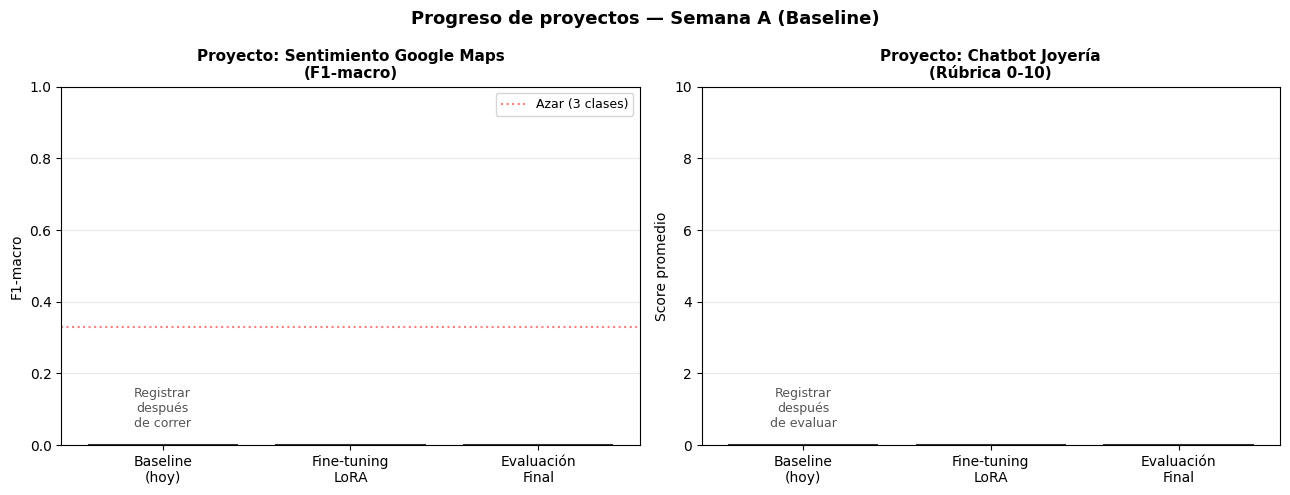

Esta gráfica la actualizarán en cada sesión conforme avancen sus proyectos.
Guárdenla en su repositorio como evidencia del progreso.


In [ ]:
# Visualización de progreso — para actualizar conforme avancen los proyectos
# Esta gráfica la actualizarán en cada sesión

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Progreso de proyectos — Semana A (Baseline)',
             fontsize=13, fontweight='bold')

# ── Proyecto 1: Sentimiento ──
fases = ['Baseline\n(hoy)', 'Fine-tuning\nLoRA', 'Evaluación\nFinal']
accuracy_sentimiento = [None, None, None]  # completar conforme avancen

axes[0].bar(fases, [0, 0, 0], color=['#90CAF9', '#E0E0E0', '#E0E0E0'],
            edgecolor='#333', linewidth=1.5)
axes[0].set_title('Proyecto: Sentimiento Google Maps\n(F1-macro)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('F1-macro')
axes[0].set_ylim(0, 1.0)
axes[0].text(0, 0.05, 'Registrar\ndespués\nde correr',
             ha='center', fontsize=9, color='#555')
axes[0].axhline(0.33, color='red', linestyle=':', alpha=0.5, label='Azar (3 clases)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Proyecto 2: Chatbot ──
axes[1].bar(fases, [0, 0, 0], color=['#A5D6A7', '#E0E0E0', '#E0E0E0'],
            edgecolor='#333', linewidth=1.5)
axes[1].set_title('Proyecto: Chatbot Joyería\n(Rúbrica 0-10)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Score promedio')
axes[1].set_ylim(0, 10)
axes[1].text(0, 0.5, 'Registrar\ndespués\nde evaluar',
             ha='center', fontsize=9, color='#555')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Esta gráfica la actualizarán en cada sesión conforme avancen sus proyectos.")
print("Guárdenla en su repositorio como evidencia del progreso.")

---
## Resumen y Siguiente Paso

**Lo que hicimos hoy:**

| Proyecto | Modelo baseline | Tarea siguiente |
|:---|:---|:---|
| Sentimiento Google Maps | `nlptown/bert-base-multilingual-uncased-sentiment` | Conseguir dataset real (200+ reseñas) |
| Asistente contable | zero-shot + RAG (TA) | Preparar documentos fiscales como corpus |
| Chatbot joyería | `flan-t5-base` + prompt con catálogo | Ampliar catálogo, evaluar 20 preguntas con rúbrica |

**Tarea para la siguiente sesión:**

Cada quien debe traer:
1. Su dataset o corpus listo (aunque sea pequeño — 50 ejemplos mínimo)
2. El baseline corrido sobre esos datos reales (no el ejemplo de hoy)
3. Una métrica registrada en su tarjeta de experimento

La siguiente sesión entramos a **fine-tuning con LoRA** — el salto cuantitativo del baseline al modelo adaptado.